In [10]:
# --- CELL 1: LIBRARIES & SETUP ---
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Feature Selection
from sklearn.feature_selection import SelectKBest, chi2

# Machine Learning Utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score, roc_curve, auc, precision_recall_curve

# Deep Learning (Keras)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Görselleştirme Ayarları
sns.set_style("whitegrid")

In [12]:
# --- CELL 2: DATA PREPARATION ---
print(" Veri Yükleniyor ve Hazırlanıyor...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# 1. Leakage (Sızıntı) Temizliği
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# 2. Feature Engineering (Yeni Özellikler)
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                       X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# 3. Preprocessing
# DİKKAT: Chi-Square negatif sayı kabul etmez. Bu yüzden MinMaxScaler kullanıyoruz.
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], verbose_feature_names_out=False)

# Hedef Değişkeni Kodla
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# 4. Split (%80 Train, %20 Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 5. Transform
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
y_train_oh = to_categorical(y_train, n_classes)
y_test_oh = to_categorical(y_test, n_classes)

feature_names = preprocessor.get_feature_names_out()

print(f" Veri Hazır: {X_train.shape}")
print(f" Toplam Özellik Sayısı: {len(feature_names)}")

 Veri Yükleniyor ve Hazırlanıyor...
 Veri Hazır: (838849, 31)
 Toplam Özellik Sayısı: 31



 Chi-Square Seçimi Başlıyor (Hedef: En İyi 20 Özellik)...
 İşlem Tamamlandı. Süre: 0.4515 sn
 Veri Boyutu İndirgendi: 31 -> 20 (Özellik Sayısı %35 Azaltıldı)

[Source: 7] Selected Top 20 Features:
['Door_Insulation_U-Value', 'Roof_Insulation_U-Value', 'Window_Insulation_U-Value', 'Wall_Insulation_U-Value', 'HVAC_Efficiency', 'Domestic_Hot_Water_Usage', 'Lighting_Density', 'Equipment_Density', 'Heating_Setpoint_Temperature', 'Air_Change_Rate', 'Total_Building_Area', 'Internal_Load_Score', 'HVAC_Load_Factor', 'Infiltration_Loss_Potential', 'Weighted_Roof_U', 'Orientation_Cos', 'Building_Type_Detached', 'Building_Type_Terraced', 'Renewable_Energy_Usage_No', 'Renewable_Energy_Usage_Yes']


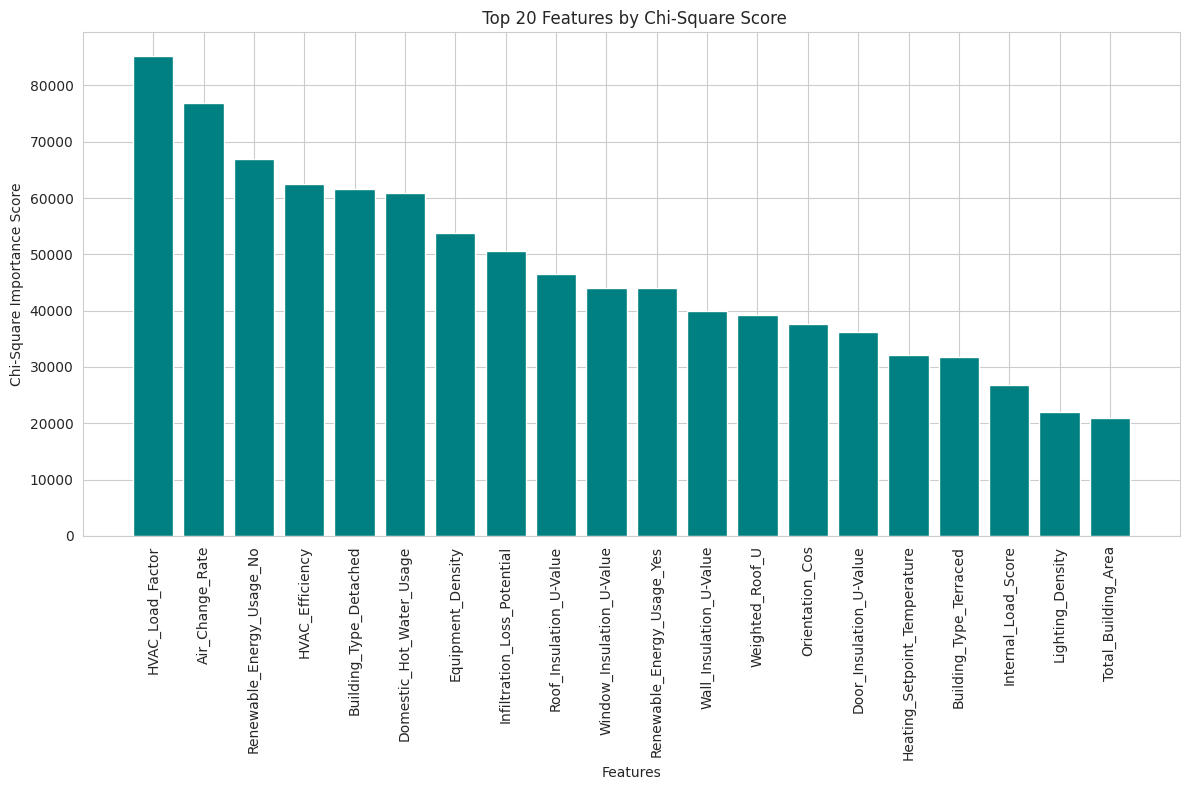

In [13]:
# --- CELL 3: CHI-SQUARE FEATURE SELECTION (k=20) ---
print("\n Chi-Square Seçimi Başlıyor (Hedef: En İyi 20 Özellik)...")
start_chi2 = time.time()

# 1. Agresif Seçim (Dirsek Yöntemi Analizine Göre k=20)
k_best = 20
selector = SelectKBest(score_func=chi2, k=k_best)
selector.fit(X_train, y_train)

# 2. Seçilenleri Belirle
mask_chi2 = selector.get_support()
X_train_chi2 = X_train[:, mask_chi2]
X_test_chi2 = X_test[:, mask_chi2]
selected_features = feature_names[mask_chi2]
chi2_scores = selector.scores_[mask_chi2]

print(f" İşlem Tamamlandı. Süre: {(time.time() - start_chi2):.4f} sn")
print(f" Veri Boyutu İndirgendi: {X_train.shape[1]} -> {X_train_chi2.shape[1]} (Özellik Sayısı %35 Azaltıldı)")
print("\n[Source: 7] Selected Top 20 Features:")
print(list(selected_features))

# 3. Görselleştirme (Rapor için)
indices = np.argsort(chi2_scores)[::-1] # Skorları büyükten küçüğe sırala
plt.figure(figsize=(12, 8))
plt.bar(range(k_best), chi2_scores[indices], align='center', color='teal')
plt.xticks(range(k_best), selected_features[indices], rotation=90)
plt.title(f' Top {k_best} Features by Chi-Square Score')
plt.ylabel('Chi-Square Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [14]:
# --- CELL 4: FINAL RESNET TRAINING (20 FEATURES) ---
print("\n Final Model Eğitimi (20 Chi-Square Özelliği + Optuna Parametreleri)...")
train_start = time.time()

# 1. Focal Loss (Sınıf Dengesizliği İçin)
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# 2. ResNet Mimarisi (Optuna Optimized)
def build_resnet_optuna(input_dim):
    input_layer = Input(shape=(input_dim,))

    # --- OPTUNA PARAMETRELERİ ---
    UNITS = 512
    N_LAYERS = 4
    ACTIVATION = 'relu'
    DROPOUT = 0.1
    LR = 0.0002053081101089717 # Optuna'dan gelen hassas LR

    # Giriş Bloğu
    x = Dense(UNITS, kernel_regularizer=l2(0.0001))(input_layer)
    x = BatchNormalization()(x)
    x = Activation(ACTIVATION)(x)
    x = Dropout(DROPOUT)(x)

    # Residual Bloklar (4 Adet)
    for _ in range(N_LAYERS):
        shortcut = x
        # Blok İçi
        x = Dense(UNITS, kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = Activation(ACTIVATION)(x)
        x = Dropout(DROPOUT)(x)

        # Skip Connection (512 + 512 -> Boyut hatası olmaz)
        x = Add()([x, shortcut])
        x = Activation(ACTIVATION)(x)

    output_layer = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    opt = Adam(learning_rate=LR)
    model.compile(loss=categorical_focal_loss(), optimizer=opt, metrics=['accuracy'])
    return model

# 3. Model Kurulumu
final_model = build_resnet_optuna(X_train_chi2.shape[1])

# 4. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint("chi2_final_k20.keras", save_best_only=True, monitor='val_accuracy', mode='max')
]

# 5. Eğitim
history = final_model.fit(
    X_train_chi2, y_train_oh,
    validation_data=(X_test_chi2, y_test_oh),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - train_start
print(f" Eğitim Süresi: {train_time/60:.2f} dk")


 Final Model Eğitimi (20 Chi-Square Özelliği + Optuna Parametreleri)...
Epoch 1/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.6747 - loss: 0.2994 - val_accuracy: 0.7801 - val_loss: 0.1359 - learning_rate: 2.0531e-04
Epoch 2/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7558 - loss: 0.1210 - val_accuracy: 0.7937 - val_loss: 0.0681 - learning_rate: 2.0531e-04
Epoch 3/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7763 - loss: 0.0669 - val_accuracy: 0.7956 - val_loss: 0.0525 - learning_rate: 2.0531e-04
Epoch 4/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7856 - loss: 0.0544 - val_accuracy: 0.8122 - val_loss: 0.0449 - learning_rate: 2.0531e-04
Epoch 5/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7899 - loss: 0.0503 - val_accuracy: 0.8109 - val_loss: 0.0443 - learning_rate: 2.0531e-04
Epoch 6/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7924 - loss: 0.0485 - val_accuracy: 0.8019 - val_loss: 0.

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step

--- Classification Report (Boruta Features) ---
              precision    recall  f1-score   support

           A     0.9571    0.9500    0.9535     43777
           B     0.9080    0.8912    0.8995     54258
           C     0.8753    0.8906    0.8829     54852
           D     0.8048    0.8089    0.8068     26453
           E     0.7613    0.7682    0.7648     14131
           F     0.6775    0.6520    0.6645      6655
           G     0.8840    0.9166    0.9000      9587

    accuracy                         0.8782    209713
   macro avg     0.8383    0.8396    0.8389    209713
weighted avg     0.8784    0.8782    0.8782    209713



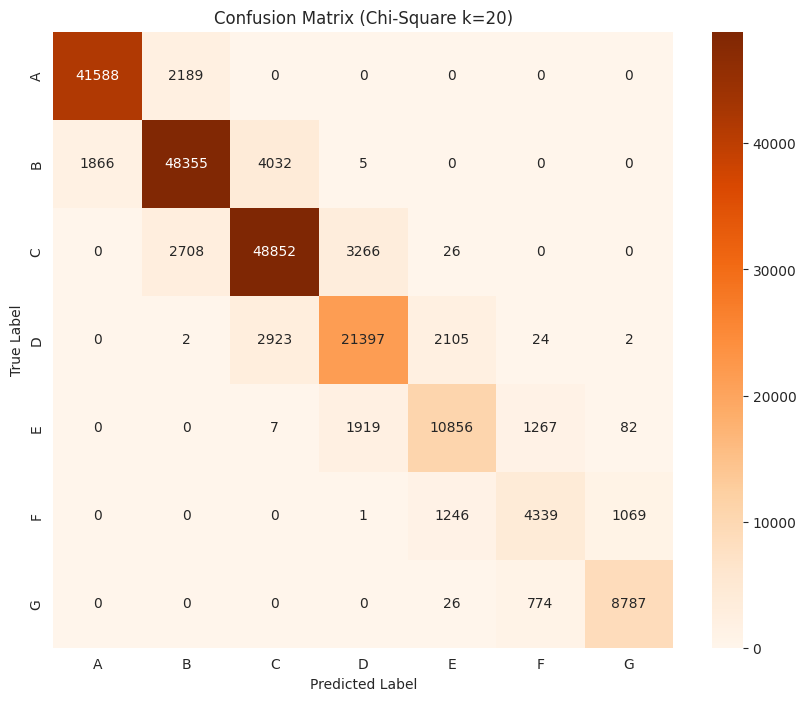

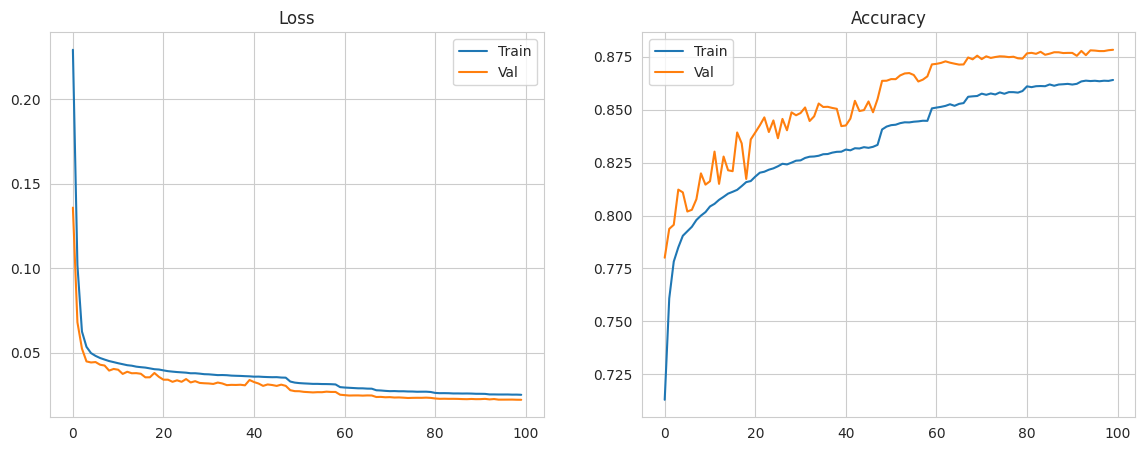


 Cohen's Kappa Score: 0.8473
 Test Accuracy: 0.8782


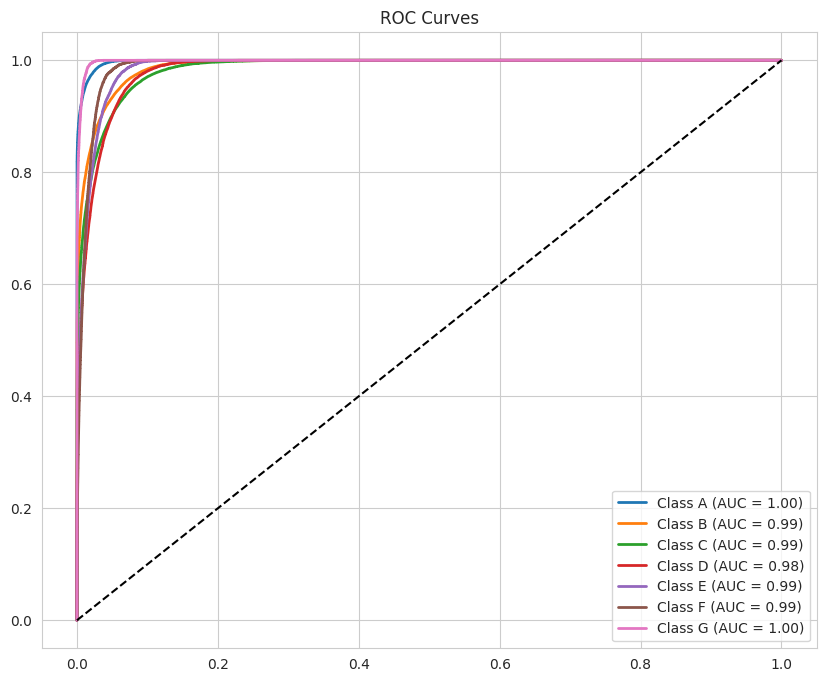

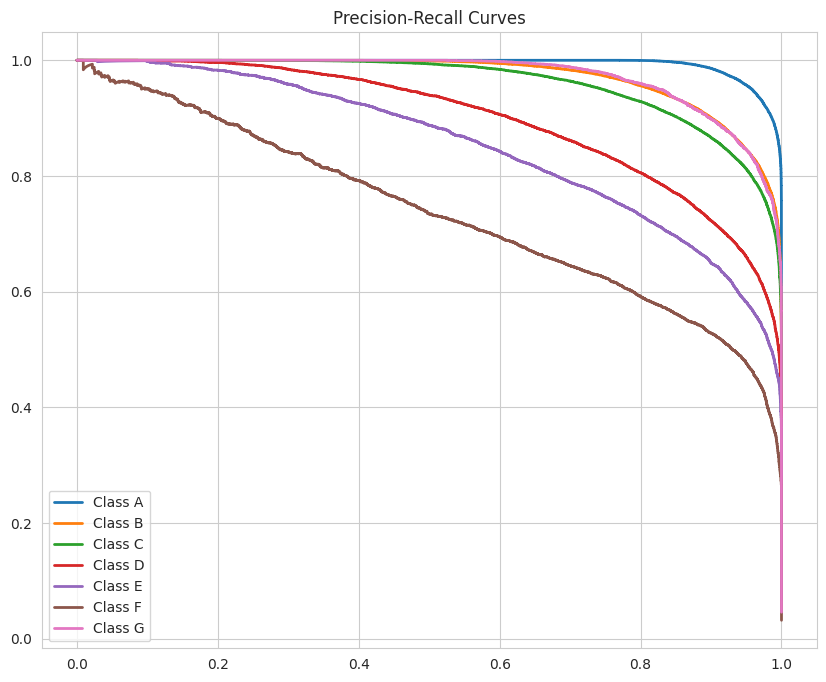

In [16]:
# --- CELL 5: REPORTING & PLOTS ---
y_pred_probs = final_model.predict(X_test_chi2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. CLASSIFICATION REPORT

print("\n--- Classification Report (Boruta Features) ---")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        digits=4
    )
)

# 2. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (Chi-Square k=20)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Training Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.show()

# 4. Metrics
print(f"\n Cohen's Kappa Score: {cohen_kappa_score(y_test, y_pred):.4f}")
print(f" Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 5. ROC & Precision-Recall
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# ROC Curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Precision-Recall Curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()